# B3b Defense – 01 Exploratory Data Analysis

**Objective:** Explore the three raw data sources for the defense market potential model.
No API calls – all data is loaded from CSV files in `data/raw/`.

| File | Series | Frequency | Unit |
|------|--------|-----------|------|
| `ADEFNO.csv` | Manufacturers' New Orders: Defense Capital Goods | Monthly | USD millions |
| `IPB52300S.csv` | Industrial Production: Defense and Space Equipment | Monthly | Index |
| `FDEFX.csv` | Federal Defense Expenditures & Gross Investment | **Quarterly** | USD millions |

**Filter: 2000-01 to 2025-12.**  
The defense sector underwent a structural break after 9/11 (late 2001), which caused a
sustained shift in both spending levels and ordering patterns. Starting from 2000 captures
the pre-break baseline while keeping the post-break regime as the primary training window.

> **Note on FDEFX:** FDEFX is reported quarterly and will be resampled to monthly
> frequency via forward-fill in Notebook 02. In this EDA notebook we work with the
> raw quarterly observations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr

DATA_RAW = '../data/raw/'

plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Section 1: Load Data

In [2]:
# Load ADEFNO (monthly)
adefno = pd.read_csv(DATA_RAW + 'ADEFNO.csv', parse_dates=['observation_date'])
adefno = adefno.rename(columns={'observation_date': 'date'})
adefno = adefno[(adefno['date'] >= '2000-01-01') & (adefno['date'] <= '2025-12-31')].copy()
adefno = adefno.sort_values('date').reset_index(drop=True)

print('ADEFNO shape:', adefno.shape)
print(adefno.dtypes)
adefno.head()

ADEFNO shape: (312, 2)
date      datetime64[us]
ADEFNO             int64
dtype: object


,date,ADEFNO
0,2000-01-01,7159
1,2000-02-01,5162
2,2000-03-01,3773
3,2000-04-01,3568
4,2000-05-01,5023


In [3]:
# Load IPB52300S (monthly)
ipb = pd.read_csv(DATA_RAW + 'IPB52300S.csv', parse_dates=['observation_date'])
ipb = ipb.rename(columns={'observation_date': 'date'})
ipb = ipb[(ipb['date'] >= '2000-01-01') & (ipb['date'] <= '2025-12-31')].copy()
ipb = ipb.sort_values('date').reset_index(drop=True)

print('IPB52300S shape:', ipb.shape)
print(ipb.dtypes)
ipb.head()

IPB52300S shape: (312, 2)
date         datetime64[us]
IPB52300S           float64
dtype: object


,date,IPB52300S
0,2000-01-01,71.0321
1,2000-02-01,69.3458
2,2000-03-01,68.6844
3,2000-04-01,67.3689
4,2000-05-01,66.5616


In [4]:
# Load FDEFX (quarterly)
# Note: FDEFX is reported quarterly and will be resampled to monthly frequency in Notebook 02.
# Here we work with the raw quarterly observations for EDA purposes.
fdefx = pd.read_csv(DATA_RAW + 'FDEFX.csv', parse_dates=['observation_date'])
fdefx = fdefx.rename(columns={'observation_date': 'date'})
fdefx = fdefx[(fdefx['date'] >= '2000-01-01') & (fdefx['date'] <= '2025-12-31')].copy()
fdefx = fdefx.sort_values('date').reset_index(drop=True)

print('FDEFX shape:', fdefx.shape)
print(fdefx.dtypes)
fdefx.head()

FDEFX shape: (104, 2)
date     datetime64[us]
FDEFX           float64
dtype: object


,date,FDEFX
0,2000-01-01,383.028
1,2000-04-01,399.592
2,2000-07-01,391.017
3,2000-10-01,396.642
4,2001-01-01,404.456


## Section 2: Missing Values & Time Coverage

In [5]:
# Missing values per series
missing = pd.DataFrame({
    'Series':         ['ADEFNO', 'IPB52300S', 'FDEFX'],
    'Total rows':     [len(adefno), len(ipb), len(fdefx)],
    'Missing values': [
        adefno['ADEFNO'].isnull().sum(),
        ipb['IPB52300S'].isnull().sum(),
        fdefx['FDEFX'].isnull().sum(),
    ]
})
print(missing.to_string(index=False))

   Series  Total rows  Missing values
   ADEFNO         312               0
IPB52300S         312               0
    FDEFX         104               0


In [6]:
# Check for gaps in monthly time coverage (ADEFNO and IPB52300S)
expected_monthly = pd.date_range('2000-01-01', '2025-12-01', freq='MS')

adefno_gaps = expected_monthly.difference(pd.DatetimeIndex(adefno['date']))
ipb_gaps    = expected_monthly.difference(pd.DatetimeIndex(ipb['date']))

print(f'ADEFNO    – expected {len(expected_monthly)} months, gaps: {list(adefno_gaps) or "none"}')
print(f'IPB52300S – expected {len(expected_monthly)} months, gaps: {list(ipb_gaps) or "none"}')

# Check quarterly coverage for FDEFX
expected_quarterly = pd.date_range('2000-01-01', '2025-10-01', freq='QS')
fdefx_gaps = expected_quarterly.difference(pd.DatetimeIndex(fdefx['date']))
print(f'FDEFX     – expected {len(expected_quarterly)} quarters, gaps: {list(fdefx_gaps) or "none"}')

ADEFNO    – expected 312 months, gaps: none
IPB52300S – expected 312 months, gaps: none
FDEFX     – expected 104 quarters, gaps: none


## Section 3: Time Series Visualization

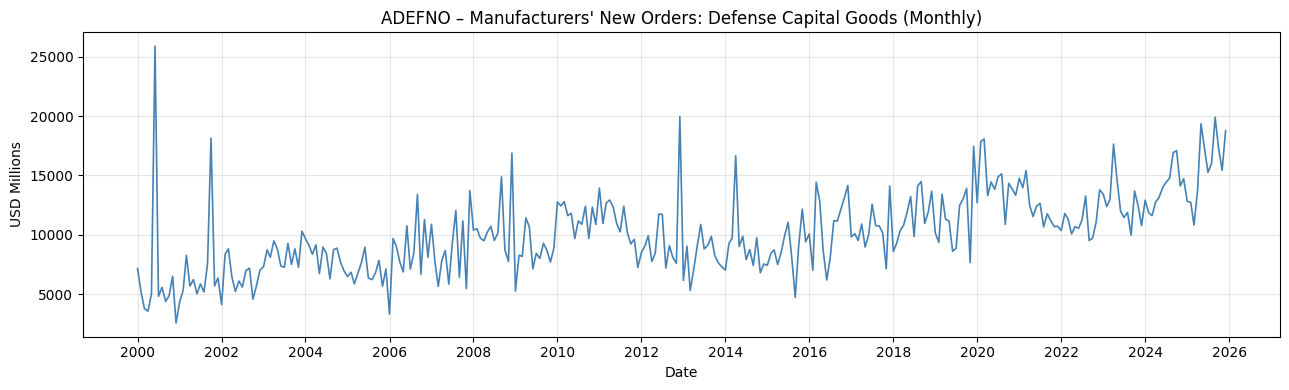

In [7]:
# Plot 1: ADEFNO (monthly, USD millions)
fig, ax = plt.subplots()
ax.plot(adefno['date'], adefno['ADEFNO'], color='steelblue', linewidth=1.2)
ax.set_title("ADEFNO – Manufacturers' New Orders: Defense Capital Goods (Monthly)")
ax.set_xlabel('Date')
ax.set_ylabel('USD Millions')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()

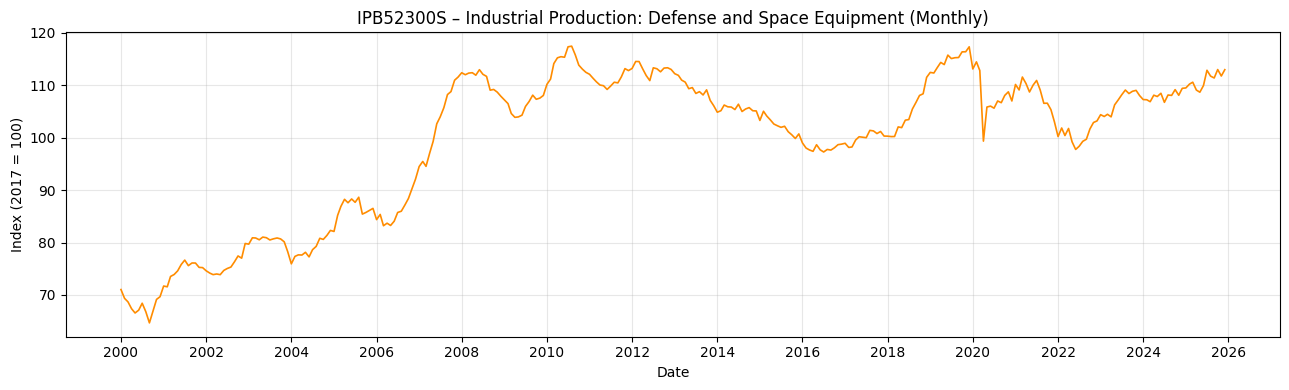

In [8]:
# Plot 2: IPB52300S (monthly, index)
fig, ax = plt.subplots()
ax.plot(ipb['date'], ipb['IPB52300S'], color='darkorange', linewidth=1.2)
ax.set_title('IPB52300S – Industrial Production: Defense and Space Equipment (Monthly)')
ax.set_xlabel('Date')
ax.set_ylabel('Index (2017 = 100)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()

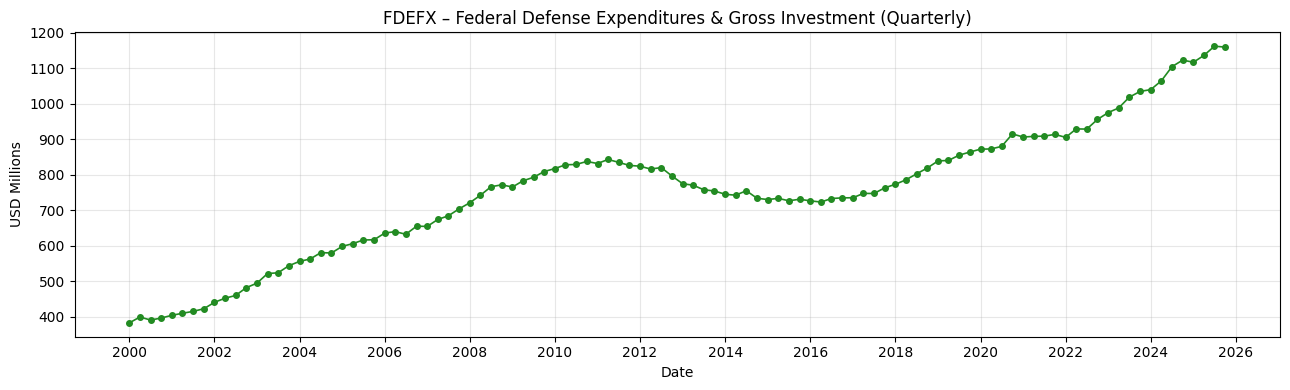

In [9]:
# Plot 3: FDEFX (quarterly – markers at actual observation dates, no interpolation)
fig, ax = plt.subplots()
ax.plot(fdefx['date'], fdefx['FDEFX'],
        color='forestgreen', linewidth=1.2, marker='o', markersize=4)
ax.set_title('FDEFX – Federal Defense Expenditures & Gross Investment (Quarterly)')
ax.set_xlabel('Date')
ax.set_ylabel('USD Millions')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()

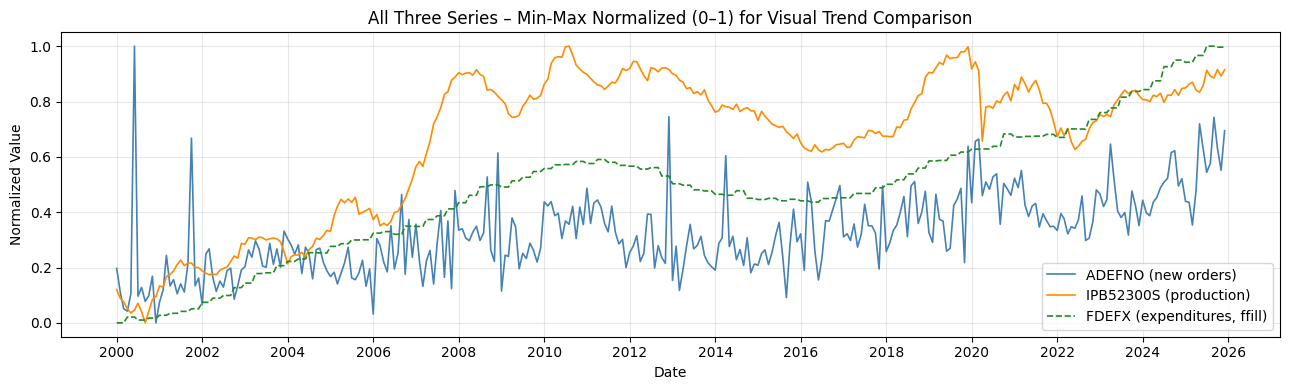

In [10]:
# Plot 4: All three series Min-Max normalized (0–1) for visual trend comparison
# Forward-fill FDEFX to monthly for this plot only – not persisted here
monthly_index = pd.date_range('2000-01-01', '2025-12-01', freq='MS')
fdefx_ffill = (
    fdefx.set_index('date')['FDEFX']
         .reindex(monthly_index)
         .ffill()
)

def minmax_norm(s):
    return (s - s.min()) / (s.max() - s.min())

adefno_s = adefno.set_index('date')['ADEFNO']
ipb_s    = ipb.set_index('date')['IPB52300S']

fig, ax = plt.subplots()
ax.plot(adefno_s.index, minmax_norm(adefno_s),
        label='ADEFNO (new orders)', color='steelblue', linewidth=1.2)
ax.plot(ipb_s.index, minmax_norm(ipb_s),
        label='IPB52300S (production)', color='darkorange', linewidth=1.2)
ax.plot(fdefx_ffill.index, minmax_norm(fdefx_ffill),
        label='FDEFX (expenditures, ffill)', color='forestgreen',
        linewidth=1.2, linestyle='--')
ax.set_title('All Three Series – Min-Max Normalized (0–1) for Visual Trend Comparison')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Value')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()

## Section 4: Descriptive Statistics

In [11]:
# Combined describe() across all three series
desc = pd.concat([
    adefno['ADEFNO'].describe().rename('ADEFNO (USD mn)'),
    ipb['IPB52300S'].describe().rename('IPB52300S (Index)'),
    fdefx['FDEFX'].describe().rename('FDEFX (USD mn, quarterly)'),
], axis=1)

print(desc.round(2))

       ADEFNO (USD mn)  IPB52300S (Index)  FDEFX (USD mn, quarterly)
count           312.00             312.00                     104.00
mean          10124.27              99.43                     754.38
std            3381.82              13.86                     185.86
min            2580.00              64.67                     383.03
25%            7668.75              88.10                     638.90
50%            9732.50             104.92                     764.31
75%           12344.25             109.85                     846.03
max           25893.00             117.45                    1161.91


**Interpretation – three complementary measurement perspectives:**

| Series | Perspective | Signal type |
|--------|-------------|-------------|
| **ADEFNO** | Orders placed with manufacturers | Leading – captures procurement *intent* |
| **IPB52300S** | Actual production output | Coincident – reflects capacity utilization |
| **FDEFX** | Realized government expenditures | Lagging – driven by budget approval cycles |

Because the three series measure different stages of the same economic pipeline
(intent → production → payment), moderate correlation is expected and desirable.
High collinearity would reduce feature informativeness for XGBoost.

## Section 5: Correlation Analysis

In [12]:
# Join ADEFNO and IPB52300S on common monthly index (inner)
df_monthly = adefno.set_index('date').join(ipb.set_index('date'), how='inner')

# Forward-fill FDEFX to monthly for correlation only – not persisted
fdefx_corr = (
    fdefx.set_index('date')['FDEFX']
         .reindex(monthly_index)
         .ffill()
)
df_corr = df_monthly.join(fdefx_corr.rename('FDEFX'), how='inner').dropna()

print('Combined shape (monthly, inner join, dropna):', df_corr.shape)
print()
print('Pearson Correlation Matrix:')
print(df_corr.corr(method='pearson').round(3))

Combined shape (monthly, inner join, dropna): (312, 3)

Pearson Correlation Matrix:
           ADEFNO  IPB52300S  FDEFX
ADEFNO      1.000      0.510  0.654
IPB52300S   0.510      1.000  0.827
FDEFX       0.654      0.827  1.000


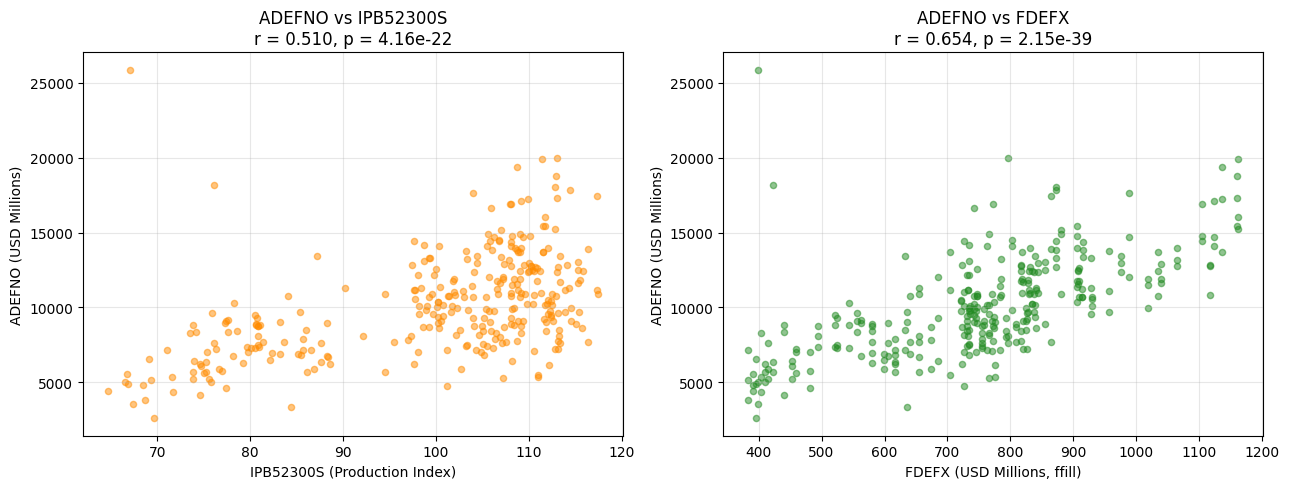

In [13]:
# Scatter plots: ADEFNO vs IPB52300S  |  ADEFNO vs FDEFX
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

r_ipb,   p_ipb   = pearsonr(df_corr['ADEFNO'], df_corr['IPB52300S'])
r_fdefx, p_fdefx = pearsonr(df_corr['ADEFNO'], df_corr['FDEFX'])

axes[0].scatter(df_corr['IPB52300S'], df_corr['ADEFNO'],
                alpha=0.5, s=20, color='darkorange')
axes[0].set_xlabel('IPB52300S (Production Index)')
axes[0].set_ylabel('ADEFNO (USD Millions)')
axes[0].set_title(f'ADEFNO vs IPB52300S\nr = {r_ipb:.3f}, p = {p_ipb:.2e}')

axes[1].scatter(df_corr['FDEFX'], df_corr['ADEFNO'],
                alpha=0.5, s=20, color='forestgreen')
axes[1].set_xlabel('FDEFX (USD Millions, ffill)')
axes[1].set_ylabel('ADEFNO (USD Millions)')
axes[1].set_title(f'ADEFNO vs FDEFX\nr = {r_fdefx:.3f}, p = {p_fdefx:.2e}')

plt.tight_layout()
plt.show()

## Section 6: Stationarity Preview – Rolling Mean of ADEFNO

A 12-month rolling mean gives a quick visual indication of whether a trend is present.
A non-flat rolling mean suggests non-stationarity, which XGBoost can handle but which
matters for feature design. Formal ADF tests and first differencing are in Notebook 02.

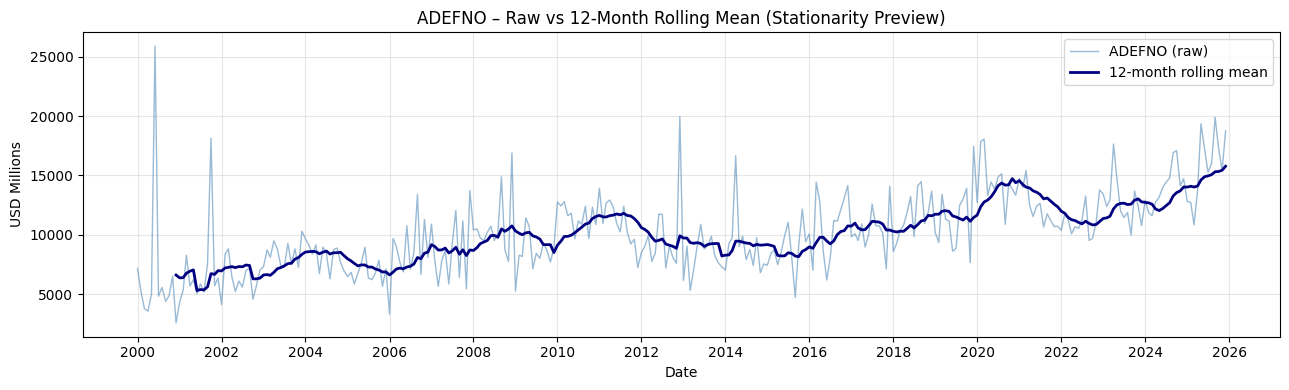

Formal ADF stationarity test and first differencing are performed in Notebook 02.


In [14]:
adefno_s     = adefno.set_index('date')['ADEFNO']
rolling_mean = adefno_s.rolling(window=12).mean()

fig, ax = plt.subplots()
ax.plot(adefno_s.index, adefno_s.values,
        label='ADEFNO (raw)', color='steelblue', linewidth=1.0, alpha=0.55)
ax.plot(rolling_mean.index, rolling_mean.values,
        label='12-month rolling mean', color='navy', linewidth=2.0)
ax.set_title('ADEFNO – Raw vs 12-Month Rolling Mean (Stationarity Preview)')
ax.set_xlabel('Date')
ax.set_ylabel('USD Millions')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()

print('Formal ADF stationarity test and first differencing are performed in Notebook 02.')